---
title: "Chapter 15: K-Means Clustering"
---

::: {.callout-lo}

By the end of this chapter, you will be able to:

- Explain the unsupervised learning paradigm and the motivation for clustering.
- Describe what a clustering algorithm produces and why there may not be one correct clustering.
- Explain the K-Means algorithm at a high level and apply scikit-learn's `KMeans`.
- Describe important strengths and limitations of K-Means, including its sensitivity to initialization and feature representation.
- Use elbow and silhouette plots to help choose the number of clusters.
- Interpret clusters in applied settings such as image clustering.
:::

Clustering looks for structure in data without using a target column. In this chapter, we will develop K-Means from its central idea, representing each group by a centre, then examine the practical choices and limitations that determine whether its clusters are useful.

**Imports**

In [1]:
import os
import random
import sys
import time

import numpy as np
import pandas as pd

sys.path.append(os.path.join(os.path.abspath(".."), "code"))

import matplotlib.pyplot as plt

from plotting_functions import *
from sklearn import cluster, datasets, metrics
from sklearn.datasets import make_blobs
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

#plt.style.use("seaborn")

plt.rcParams["font.size"] = 12
plt.rcParams["figure.figsize"] = (5, 4)

## Before you begin

Look at the foods below and consider either of the following questions before continuing.

![](img/food-clustering-activity.png)

- Categorize the food items in the image and write your categories. Do you think there is one correct way to cluster these images? Why or why not?
- If you want to build a machine learning model to cluster such images how would you represent such images?

## Why cluster data?

### The "perfect" spaghetti sauce

Suppose a company wants to make the one "perfect" spaghetti sauce. Customer preferences differ, so one recipe is unlikely to satisfy everyone. Howard Moskowitz's market research instead identified groups of customers who preferred plain, spicy, or extra-chunky sauces. Designing products for these groups proved more useful than optimizing a single average product.

![](img/prego-pasta-sauces.png)

Clustering asks whether similar groups can be found in data even when no group labels are provided. The sauce story is discussed in [Malcolm Gladwell's TED talk](https://www.ted.com/talks/malcolm_gladwell_choice_happiness_and_spaghetti_sauce?language=en).

<br><br>

### What is clustering?

In supervised learning, each training example has features $X$ and a target $y$, and the goal is to predict the target of a new example. In **unsupervised learning**, we have $X$ but no target. The goal is instead to find useful structure in the feature data.

**Clustering** is an unsupervised task that partitions examples into groups called clusters. A useful clustering places similar examples together and dissimilar examples apart. What counts as "similar" depends on the feature representation, distance measure, and purpose of the analysis.

<br><br>

### Clustering input and possible output

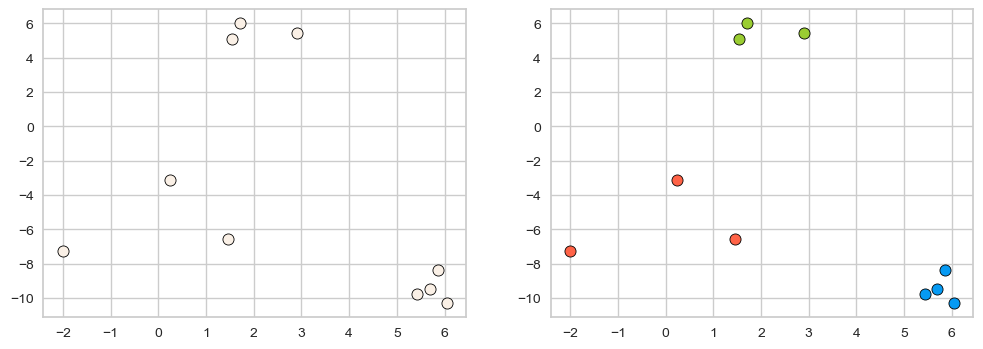

In [2]:
X, y = make_blobs(n_samples=10, centers=3, n_features=2, random_state=10)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
discrete_scatter(X[:, 0], X[:, 1], ax = axes[0]); # user-defined plotting function defined in code/plotting_functions.py
discrete_scatter(X[:, 0], X[:, 1], y=y, markers='o', ax = axes[1]);

The left plot below contains only the feature matrix $X$. The colours on the right illustrate one possible assignment of each example to a cluster.

Cluster labels are arbitrary identifiers: changing labels 0, 1, and 2 to 2, 0, and 1 does not change the grouping. Unlike a supervised target, these numbers have no meaning on their own. In practice, we may not know how many clusters exist—or whether the data contains useful clusters at all.

#### Example 1: What is "correct" grouping?
Which of the following grouping of emoticons is the "correct" grouping?

![](img/emoticon_clustering_example.png)

<!-- <img src="img/emoticon_clustering_example.png" alt="" height="800" width="800">  -->

Both groupings are reasonable: one uses facial expression and the other uses whether the emoticon includes a nose.

There is therefore no universally correct grouping. Domain knowledge and the intended use determine whether a clustering is meaningful, which also makes clustering quality difficult to measure with a single number.

<br><br>

### Why clustering can be useful

Clustering can summarize a dataset, reveal groups for further investigation, or partition examples before another analysis. For example, after fitting a supervised model, we might inspect its performance separately on discovered clusters to find a group on which it performs poorly. The clusters still require interpretation; the algorithm does not explain what they mean.

#### Customer segmentation

- Understand landscape of the market in businesses and craft targeted business or marketing strategies tailored for each group.

![](img/customer-segmentation.png)

<!-- <img src="img/customer-segmentation.png" alt="" height="600" width="600">  -->

[source](https://www.youtube.com/watch?v=zPJtDohab-g&t=134s)

#### Document clustering

Grouping articles on different topics from different news sources. For example, [Google News](https://news.google.com). 

![](img/google_news.png)

<!-- <img src="img/google_news.png" alt="" height="1200" width="1200">  -->
    
**You'll be working on document clustering, image clustering, and multimodal clustering in the lab.**

Other applications include social-network analysis, image segmentation, anomaly detection, and data compression.

<br><br><br><br><br><br>

## K-Means clustering

K-Means defines similarity using Euclidean distance, just as $k$-nearest neighbours does. It represents each cluster by a centre and assigns nearby examples to that centre.

K-Means takes two inputs:

- `X` $\rightarrow$ a set of data points  
- `K` (or $k$ or `n_clusters`) $\rightarrow$ number of clusters

It returns one of `K` cluster labels for each example and learns `K` cluster centres.

We will begin with the toy dataset above, where three compact groups are visually apparent.

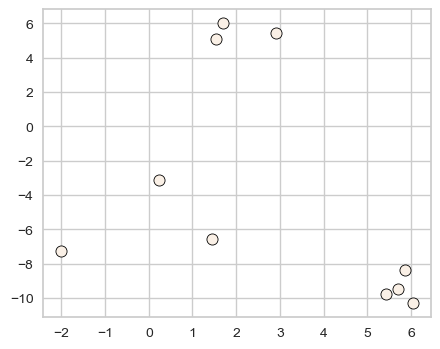

In [3]:
X, y = make_blobs(n_samples=10, centers=3, n_features=2, random_state=10)
discrete_scatter(X[:, 0], X[:, 1]);

We set `n_clusters=3` and pass only `X` to `fit`; clustering does not use target labels.

In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X); # We are only passing X because this is unsupervised learning

`predict` returns the cluster assignment for each example.

In [5]:
clust_labels = kmeans.predict(X)
clust_labels

array([1, 0, 2, 0, 1, 1, 2, 2, 0, 1], dtype=int32)

For the data used during fitting, the same assignments are stored in `labels_`.

In [6]:
kmeans.labels_

array([1, 0, 2, 0, 1, 1, 2, 2, 0, 1], dtype=int32)

In [7]:
toy_clust_df = pd.DataFrame(X, columns = ['feat1', 'feat2'])
toy_clust_df['cluster labels'] = clust_labels
toy_clust_df

,feat1,feat2,cluster labels
0,5.691924,-9.476412,1
1,1.707899,6.004352,0
2,0.236210,-3.119100,2
3,2.901595,5.421215,0
4,5.859439,-8.381924,1
5,6.047749,-10.305047,1
6,-2.007588,-7.247439,2
7,1.454677,-6.583872,2
8,1.536362,5.111215,0
9,5.430704,-9.759561,1


The learned cluster centres are stored in `cluster_centers_`.

In [8]:
cluster_centers = kmeans.cluster_centers_
cluster_centers

array([[ 2.04861878,  5.51226051],
       [ 5.75745416, -9.48073598],
       [-0.10556679, -5.65013704]])

Let's plot clustered data points and their corresponding centers. 

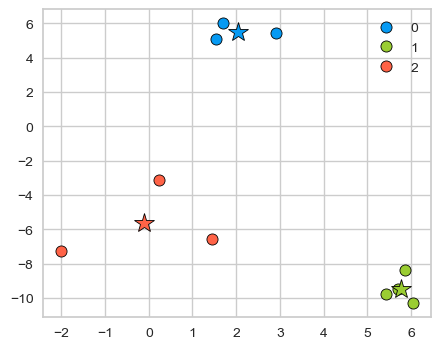

In [9]:
km_labels = kmeans.labels_
discrete_scatter(X[:, 0], X[:, 1], kmeans.labels_, c=kmeans.labels_, markers="o");
plt.legend();
discrete_scatter(cluster_centers[:, 0], cluster_centers[:, 1], y =[0,1,2], s=15, markers='*');

The stars mark the **centroids**, or means of the examples assigned to each cluster. A centroid lies in the feature space but is not usually an observed example.

A fitted K-Means model can also assign new examples to their nearest learned centroid.

Consider the two new query points shown with triangles below. 

In [10]:
new_examples = np.array([[-2, -2.5], [2, 4]])
kmeans.predict(new_examples)

array([2, 0], dtype=int32)

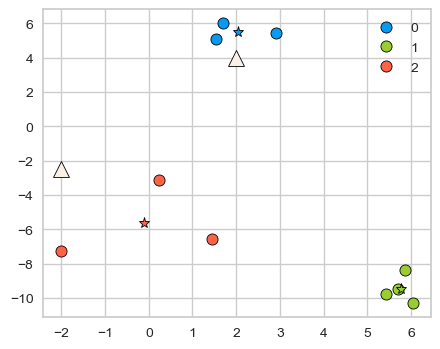

In [11]:
discrete_scatter(X[:, 0], X[:, 1], kmeans.labels_, markers="o")
plt.legend()
discrete_scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], y=[0,1,2], markers="*"
);
discrete_scatter(new_examples[:, 0], new_examples[:, 1], markers="^",s=11);

In [12]:
kmeans.predict(new_examples).tolist()

[2, 0]

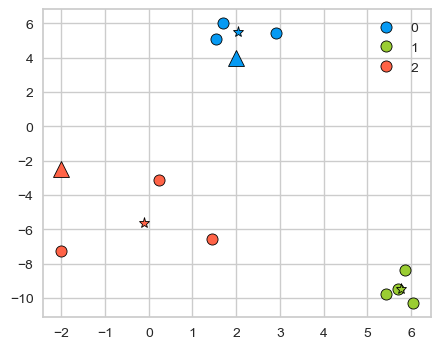

In [13]:
discrete_scatter(X[:, 0], X[:, 1], kmeans.labels_, markers="o")
plt.legend()
discrete_scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], y=[0,1,2], markers="*"
);
discrete_scatter(new_examples[:, 0], new_examples[:, 1], y=kmeans.predict(new_examples).tolist(), markers="^",s=11);

### The K-Means algorithm

If the centres were known, we could assign each example to its nearest centre. If the assignments were known, we could compute each centre by taking a mean. K-Means resolves this circular dependency by alternating between these two operations.

Starting from $K$ initial centres, the algorithm repeats two steps:

1. **Assignment:** assign every example to its nearest centre.
2. **Update:** replace each centre with the mean of the examples assigned to it.

It stops when the centres no longer change enough or when it reaches the maximum number of iterations.

<br><br><br>

### A worked K-Means example
Let's execute K-Means algorithm on our toy example. 

**Input**
- The data points `X`

In [14]:
n_examples = X.shape[0]
print("Number of examples: ", n_examples)
X

Number of examples:  10


array([[  5.69192445,  -9.47641249],
       [  1.70789903,   6.00435173],
       [  0.23621041,  -3.11909976],
       [  2.90159483,   5.42121526],
       [  5.85943906,  -8.38192364],
       [  6.04774884, -10.30504657],
       [ -2.00758803,  -7.24743939],
       [  1.45467725,  -6.58387198],
       [  1.53636249,   5.11121453],
       [  5.4307043 ,  -9.75956122]])

- Let K (number of clusters) be 3. 

In [15]:
k = 3

**Initialization**

- Random initialization for K initial centers of the clusters. 

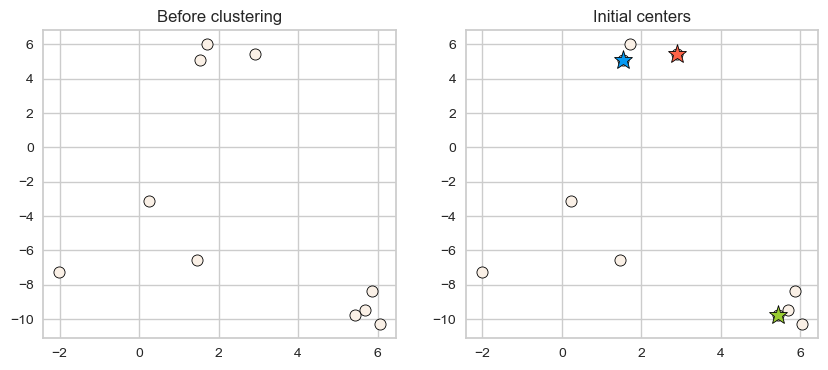

In [16]:
np.random.seed(seed=3)
centers_idx = np.random.choice(range(0, n_examples), size=k)
centers = X[centers_idx]
plot_km_initialization(X, centers) # user-defined plotting function defined in code/plotting_functions.py

**Iterative process**

repeat 

- Assign each example to the closest center. (`update_Z`)
- Estimate new centers as _average_ of observations in a cluster. (`update_centers`)

until **centers stop changing** or **maximum iterations have reached**.

- First step in the iterative process is assigning examples to the closest center. How to find closest centers? 

- Let's consider distance of an example to all centers and assign that example to the closest center.  


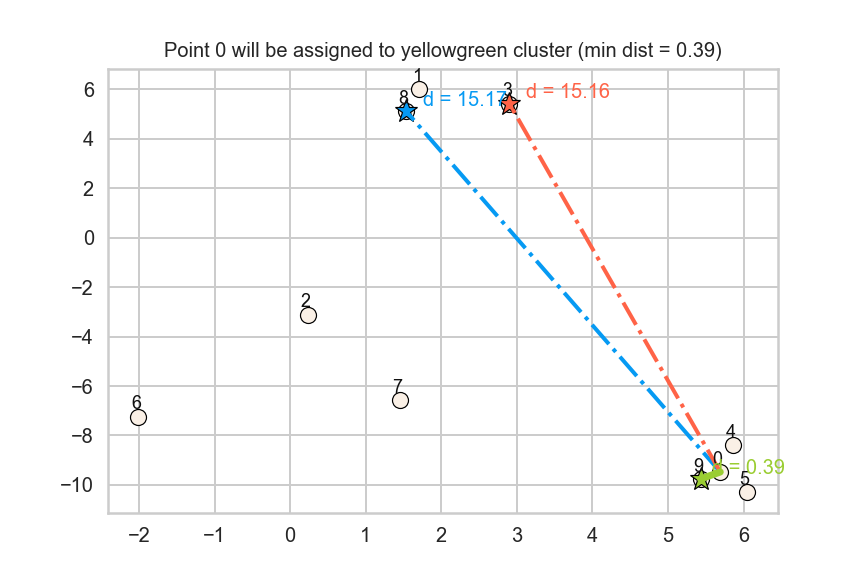
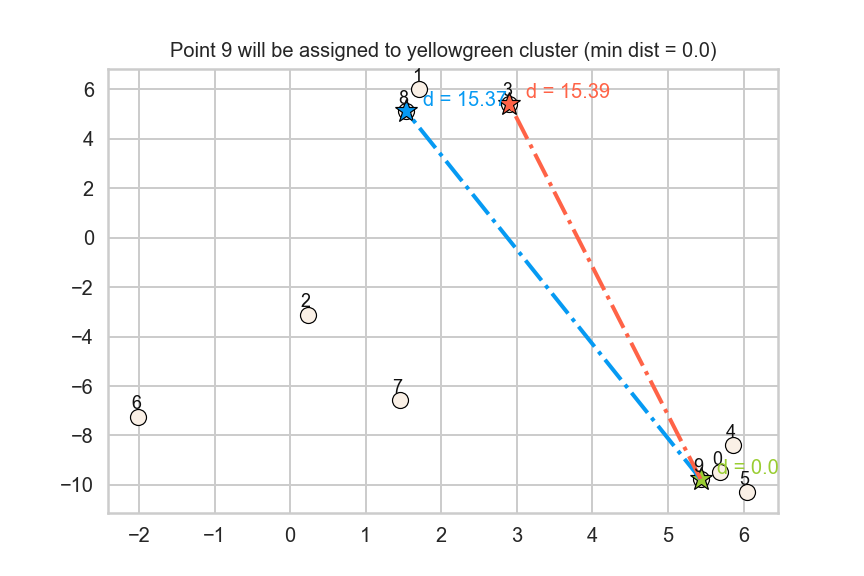
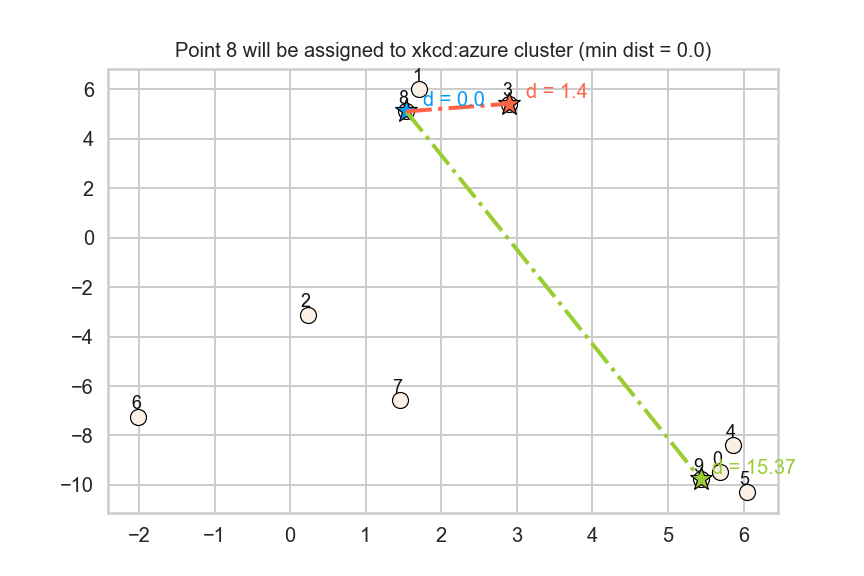
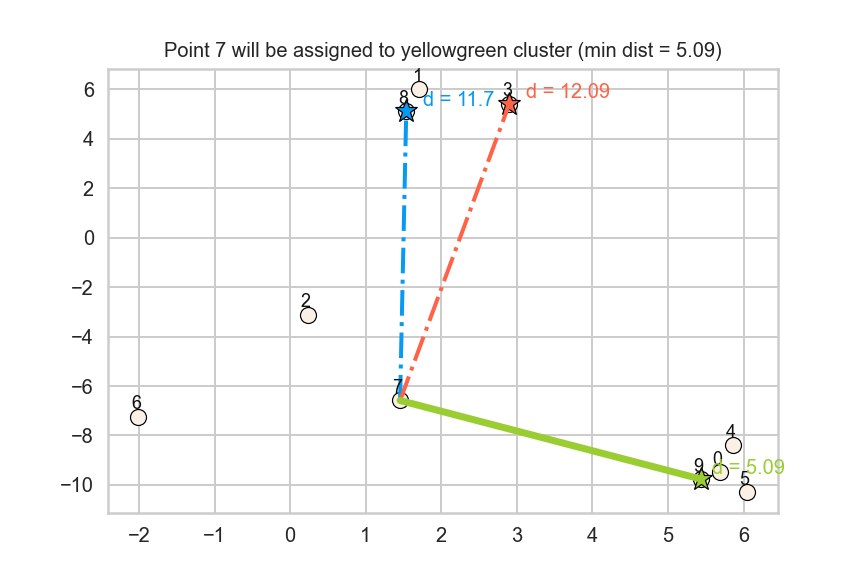
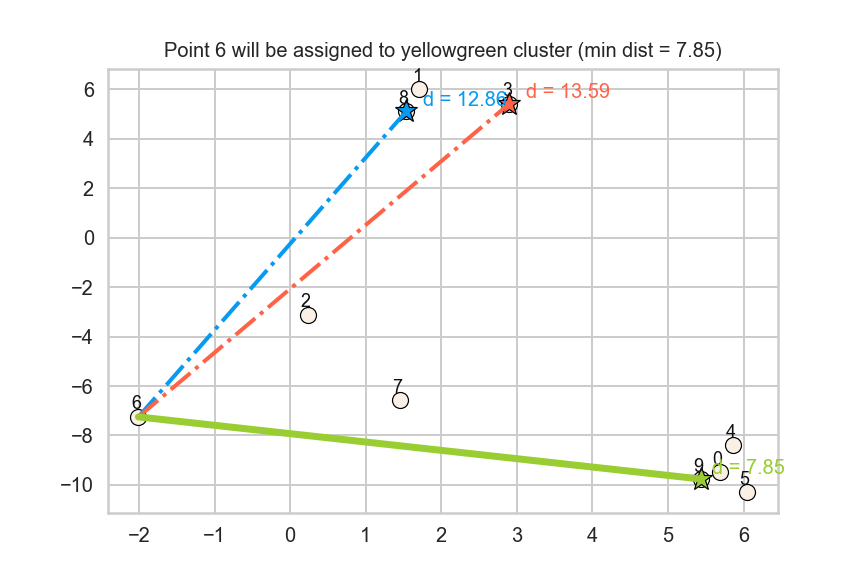
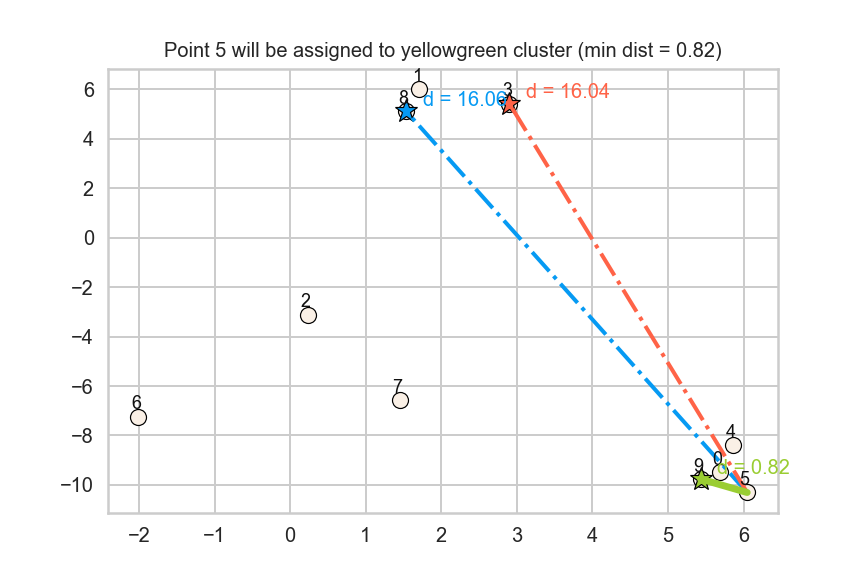
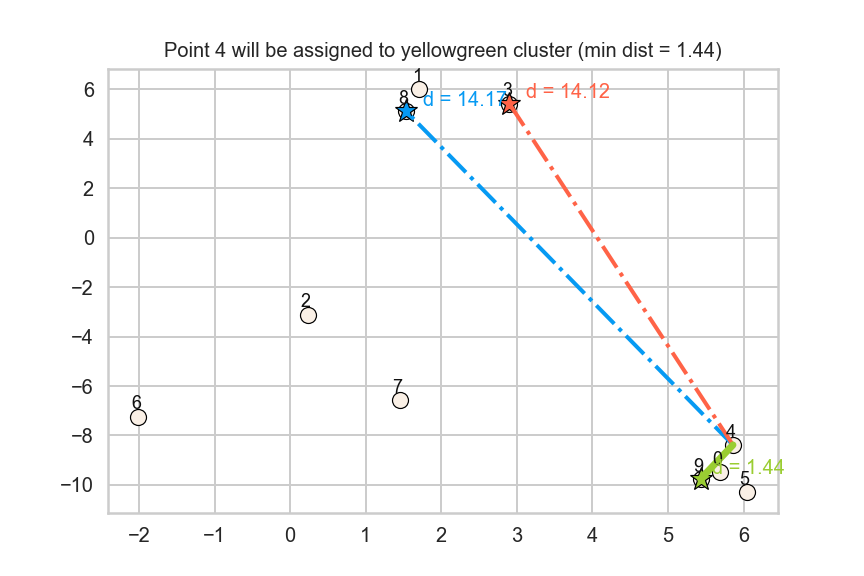
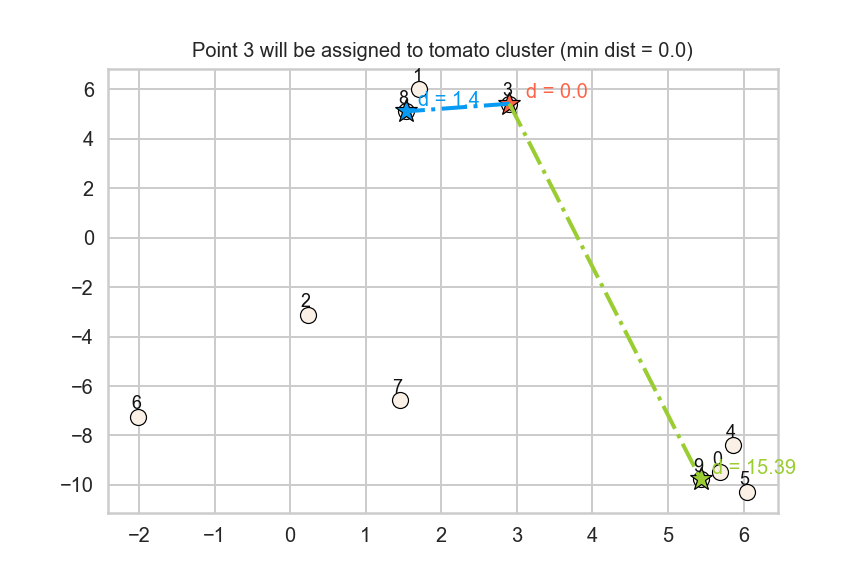
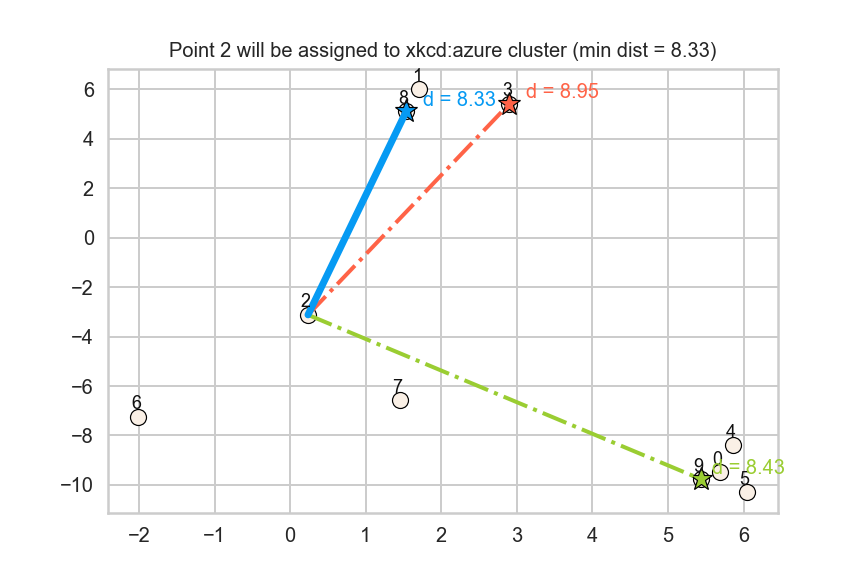
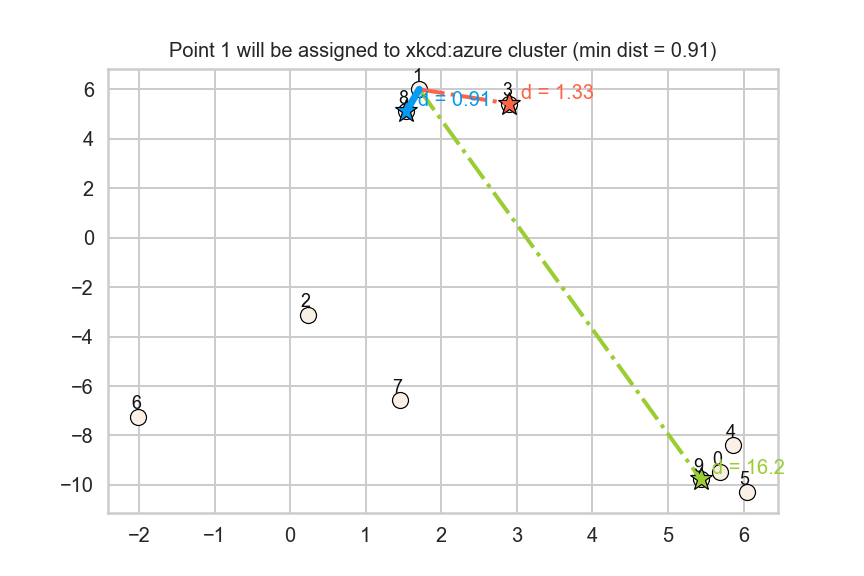
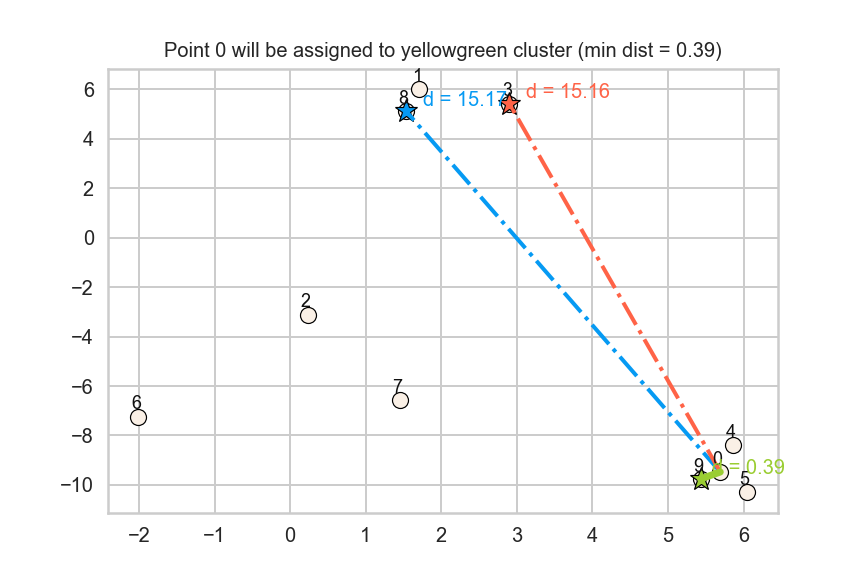

In [17]:
import panel as pn
from panel import widgets
from panel.interact import interact
import matplotlib.pyplot as plt

pn.extension()

def f(point_index):
    fig = plt.figure(figsize=(6, 4))
    # user-defined plotting function defined in code/plotting_functions.py
    return plot_example_dist(X, centers, fig, point_ind=point_index)
    
interact(f, point_index=widgets.FloatSlider(start=0, end=9, step=1, value=0)).embed(max_opts=9)
# interact(f, point_index=widgets.FloatSlider(start=0, end=9, step=1, value=0))

- Similarly, we can make cluster assignments for all points by calculating distances of all examples to the centers and assigning it to the cluster with smallest distance.  

In [18]:
from sklearn.metrics import euclidean_distances

def update_Z(X, centers):
    """
    returns distances and updated cluster assignments
    """
    dist = euclidean_distances(X, centers)
    return dist, np.argmin(dist, axis=1)

- With the new cluster assignments for our data points, we update cluster centers. How do we update centers? 

- New cluster centers are means of data points in each cluster. 

In [19]:
def update_centers(X, Z, old_centers, k):
    """
    returns new centers
    """
    new_centers = old_centers.copy()
    for kk in range(k):
        new_centers[kk] = np.mean(X[Z == kk], axis=0)
    return new_centers

Let's put these steps together. 
- Initialize
- Iteratively alternate between the following two steps.
    - **Update assignments** $Z \rightarrow$ Assign each example to the closest center
    - **Update centers** $\rightarrow$ Estimate new centers as _average_ of examples in a cluster

Let's examine the initial centers. 

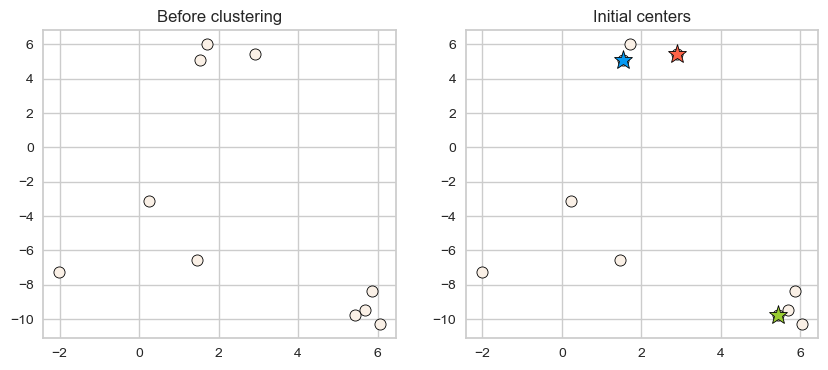

In [20]:
plot_km_initialization(X, centers)

Here is the path cluster centers took and their cluster assignements in six iterations. 

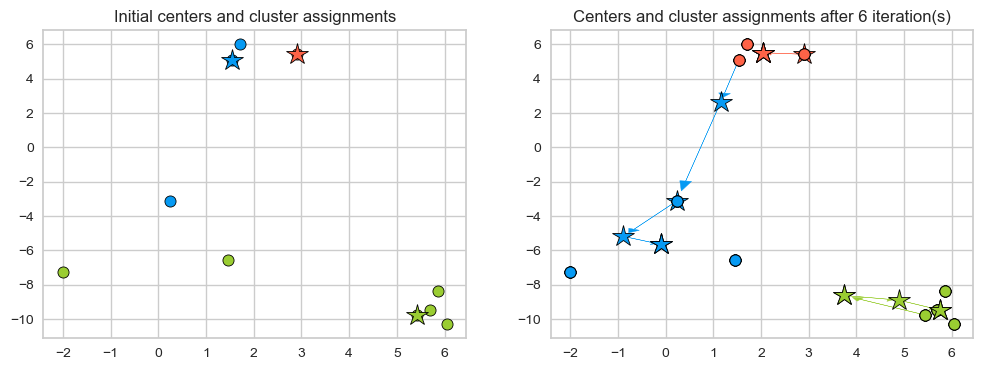

In [21]:
plot_km_iterative(X, X[centers_idx], 6) # user-defined plotting function defined in code/plotting_functions.py

<br><br><br>

### Initialization matters

K-Means can converge to different solutions from different initial centres. The next example shows how a poor initialization can produce a worse grouping.

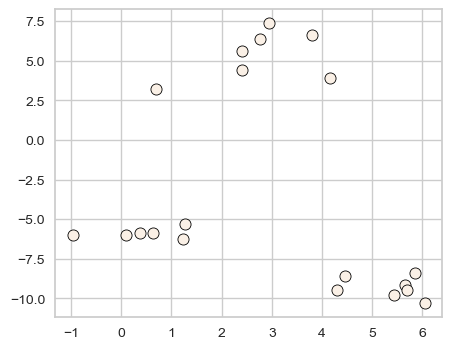

In [22]:
X_init, y_init = make_blobs(n_samples=20, centers=3, n_features=2, random_state=10)
discrete_scatter(X_init[:, 0], X_init[:, 1], markers="o");

In [23]:
k = 3
n_examples = X_init.shape[0]

**Example: Bad initialization**

In [24]:
np.random.seed(seed=10)
centroids_idx_init = np.random.choice(range(0, n_examples), size=k)
centroids = X_init[centroids_idx_init]

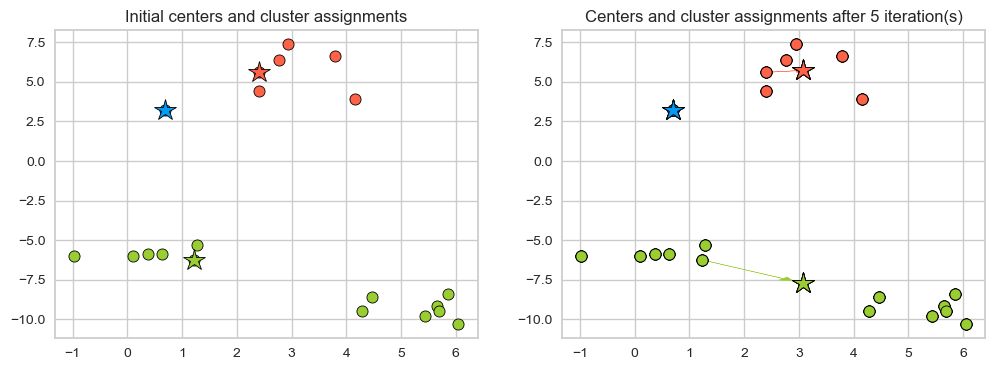

In [25]:
plot_km_iterative(X_init, X_init[centroids_idx_init], 5)

**Example: Better initialization**
The following initialization seems much better. 

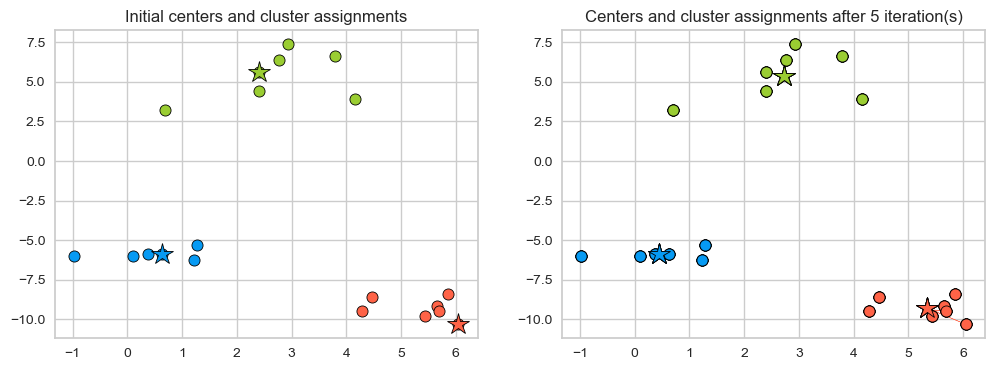

In [26]:
np.random.seed(seed=2)
centroids_idx = np.random.choice(range(0, n_examples), size=k)
plot_km_iterative(X_init, X_init[centroids_idx], 5)

**Reducing sensitivity to initialization**

Scikit-learn uses **K-Means++** by default, which spreads the initial centres apart. The `n_init` parameter controls how many initializations are tried; `KMeans` retains the run with the lowest within-cluster sum of squares. A fixed `random_state` makes the result reproducible.

### When K-Means works well

K-Means is simple and usually efficient, but its Euclidean-distance objective makes several implicit assumptions. It works best when clusters are compact, roughly spherical, similarly sized, and reasonably well separated.

Feature scale matters because a feature with a large numeric range can dominate the distance calculation. As with $k$-nearest neighbours, numeric features should usually be scaled before fitting K-Means. Feature representation matters just as much: clustering images by raw pixel values, for example, can produce very different groups than clustering representations that encode visual content.

K-Means is also sensitive to outliers. Because each centroid is a mean, an extreme example can pull its centroid away from the rest of the cluster. Finally, every example receives exactly one cluster label, even when it lies between groups or does not belong naturally to any cluster.

### Optional details about K-Means

**(Optional) Objective function for K-Means**

- Find the local minimum of minimizing squared distances (L2 norm).  

- The algorithm optimizes the sum of the distances of the cluster centers to all the points in that cluster. In other words, it minimizes within-cluster sum-of-squares criterion. 

$$\sum_{i=1}^k\sum_{j=1}^n u_{ij}\lVert{\mathbf{x}_j-\mathbf{c}_i}\rVert^2_2$$

- $u_{ij}$ is 1 if the point $\mathbf{x}_j$ belongs to cluster $i$, and 0 otherwise
- $\mathbf{c}_i$ is the centroid of the $i^{th}$ cluster

- It's an NP hard problem and we cannot hope to solve it exactly but the K-Means algorithm we saw provides us a local minimum.  

The algorithm above is called **Lloyd's algorithm**. More details [here](https://scikit-learn.org/stable/modules/clustering.html#k-means). 

**(Optional) Why not use gradient descent?**

- The partition matrix ${\mathbf{U}}=[u]_{ij}$ is discrete, so we cannot use gradients to help us minimize;

- Hence, the iterative approach:
    1. Obtain the centroid
    
    2. Change the partition

**(Optional) Distances in K-Means**

- We are using the L2 norm here to calculate distances.

    $$\lVert{\mathbf{x}_j-\mathbf{c}_i}\rVert^2_2$$ 

- We can use a different distance metrics; but then, 

    - it won't be K-Means anymore, as the very idea of mean is based on Euclidean distance. 

- K-Means can be thought as a special case of the expectation maximization algorithm. 

**(Optional) Feature engineering using K-Means**

- K-Means could be used for feature engineering in supervised learning. 

- Examples: 
    - You could add a categorical feature: cluster membership
    
    - You could add a continuous features: distance from each cluster center
- See [this paper](http://ai.stanford.edu/~acoates/papers/coatesleeng_aistats_2011.pdf).

**(Optional) Time complexity of K-Means**

- Naive implementation of K-Means requires you to compute the distances from all data points to all cluster centers. 

- So there are many distance calculations per iteration. 
- calculating assigning observations to centers is heavy: $\mathcal{O(ndk)}$
- updating centers is light(er): $\mathcal{O(nd)}$

where, 

- $n \rightarrow$ number of examples
- $d \rightarrow$ number of features
- $k \rightarrow$ number of clusters

- There are more efficient exact algorithms. 
    - Elkan's (implemented in `scikit-learn`)
    - Ying-Yang
- Here, the meaning of exact is that they give you exactly the same result as the Lloyd's algorithm but do that more efficiently.      
- Also, other approximate algorithms are being developed. 

<br><br><br><br>

## Exercises

### Exercise 1

Select all statements that are true.

- (A) K-Means algorithm always converges to the same solution.

- (B) $K$ in K-Means should always be $\leq$ # of features.
- (C) In K-Means, it makes sense to have $K$ $\leq$ # of examples. 
- (D) In K-Means, in some iterations some points may be left unassigned. 

::: {.callout-tip collapse="true"}
## Solution

- C
:::

<br><br><br><br>

### Exercise 2

Select all statements that are true.

- (A) K-Means is sensitive to initialization and the solution may change depending upon the initialization. 

- (B) K-means terminates when the number of clusters does not increase between iterations.
- (C) K-means terminates when the centroid locations do not change between iterations.
- (D) K-Means is guaranteed to find the optimal solution. 


::: {.callout-tip collapse="true"}
## Solution

- A, C
:::

<br><br><br><br>

## Choosing the number of clusters

K-Means requires `n_clusters` in advance. Without target labels, we cannot select $K$ using supervised validation scores. Domain knowledge should guide the choice whenever possible; elbow and silhouette plots provide additional evidence, not an automatic answer.

### The elbow method

**Inertia** is the sum of squared distances from each example to its assigned centroid. For three clusters,

$$\sum_{P_i \in C_1}  distance(P_i, C_1)^2 + \sum_{P_i \in C_2}  distance(P_i, C_2)^2 + \sum_{P_i \in C_3} distance(P_i, C_3)^2$$

where

$C_1,C_2,C_3$ are the centroids and each $P_i$ is an example assigned to that cluster.

Scikit-learn stores inertia in the fitted model's `inertia_` attribute.

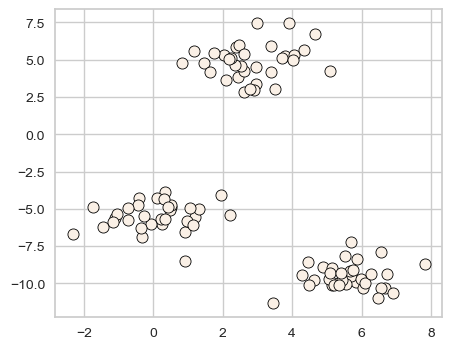

In [27]:
XX, y = make_blobs(centers=3, n_features=2, random_state=10)
discrete_scatter(XX[:, 0], XX[:, 1], markers="o");

In [28]:
d = {"K": [], "inertia": []}
for k in range(1, 100, 10):
    model = KMeans(n_clusters=k, n_init='auto').fit(XX)
    d["K"].append(k)
    d["inertia"].append(model.inertia_)

In [29]:
pd.DataFrame(d)

,K,inertia
0,1,4372.460950
1,11,70.076284
2,21,26.137410
3,31,15.359887
4,41,6.844921
5,51,3.593508
6,61,2.126488
7,71,1.016676
8,81,0.385639
9,91,0.053156


Inertia always decreases as $K$ increases; with one cluster per example, it reaches zero. The elbow method therefore looks for a bend after which additional clusters yield only small reductions in inertia. It balances compact clusters against a simpler clustering with fewer groups.

In [30]:
def plot_elbow(w, h, inertia_values):
    plt.figure(figsize=(w, h))
    plt.axvline(x=3, linestyle="-.", c="black")
    plt.plot(range(1, 10), inertia_values, "-o")
    ax = plt.gca()
    ax.tick_params("both", labelsize=(w + h))
    ax.set_xlabel("K", fontsize=w+h)
    ax.set_ylabel("Inertia", fontsize=w+h)

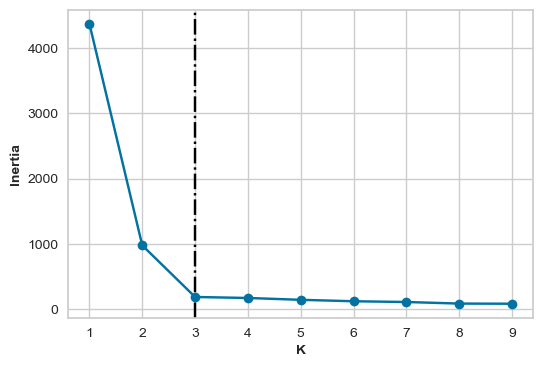

In [31]:
inertia_values = list()
for k in range(1, 10):
    inertia_values.append(KMeans(n_clusters=k, n_init='auto').fit(XX).inertia_)
plot_elbow(6, 4, inertia_values)

Here, $K=3$ is a reasonable choice: beyond three clusters, the improvement is comparatively small. Real elbow plots are often ambiguous.

The [`yellowbrick`](https://www.scikit-yb.org/en/latest/api/cluster/elbow.html) package provides a convenient elbow visualizer.

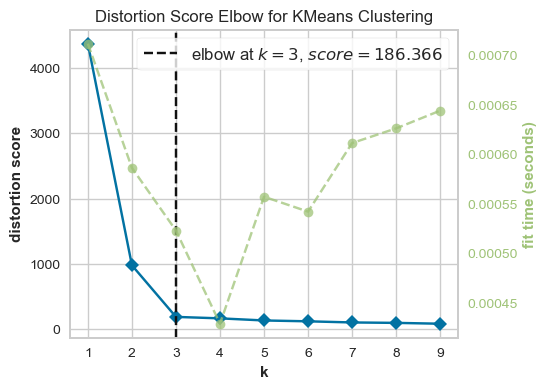

In [32]:
from yellowbrick.cluster import KElbowVisualizer

model = KMeans()
visualizer = KElbowVisualizer(model, k=(1, 10))

visualizer.fit(XX)  # Fit the data to the visualizer
visualizer.show();

<br><br>

### The silhouette method

The silhouette score compares how close an example is to its own cluster with how close it is to the nearest alternative cluster. It can be used with clustering methods that do not define centroids.

**Mean intra-cluster distance ($a$)**

- Consider the green point below. 

- The mean intra-cluster distance for the point is the average of the distances of the green point to the other points in the same cluster.

  - These distances are represented by the black lines in the plot below. 
  

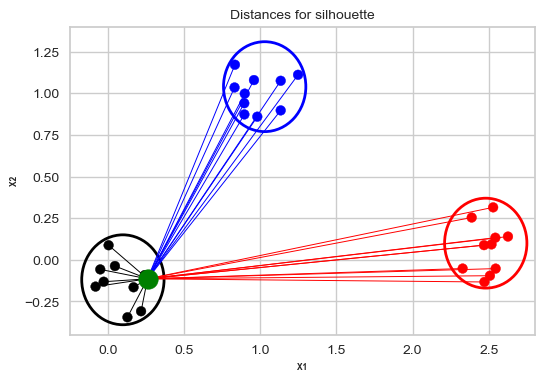

In [33]:
plot_silhouette_dist(6, 4)

**Mean nearest-cluster distance ($b$)**

- Average of the distances of the green point to the blue points is smaller than the average of the distances of the green point to the red points. So the **nearest cluster** is the blue cluster. 

- So, the mean nearest-cluster distance is the average of the distances of the green point to the blue points.  

**Silhouette distance for a data point**

- The silhouette distance for a data point the difference between the **the average nearest-cluster distance** ($b$) and **average intra-cluster distance** ($a$) for each data point, normalized by the maximum value

$$\frac{b-a}{max(a,b)}$$

- The best value is 1. 

- The worst value is -1 (samples have been assigned to wrong clusters).

- Value near 0 means overlapping clusters i.e., the example is on or very close to the decision boundary between two neighbouring clusters.  

The overall **Silhouette score** is the average of the Silhouette scores for all examples. We can visualize the silhouette score for each example individually in a silhouette plot (hence the name), see below.

**Using Silhouette scores to select the number of clusters**

- The plots below show the Silhouette scores for each sample in that cluster. 

In [34]:
from yellowbrick.cluster import SilhouetteVisualizer

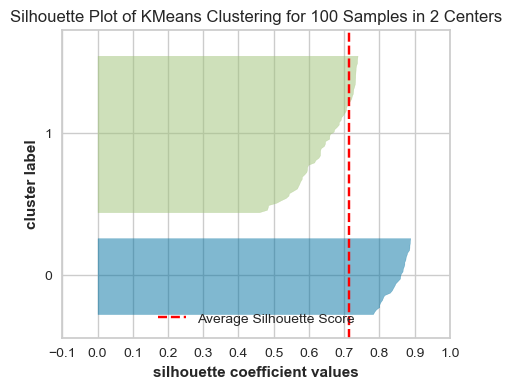

In [35]:
model = KMeans(2, n_init='auto', random_state=42)
visualizer = SilhouetteVisualizer(model, colors="yellowbrick")
visualizer.fit(XX)  # Fit the data to the visualizer
visualizer.show();
# Finalize and render the figure

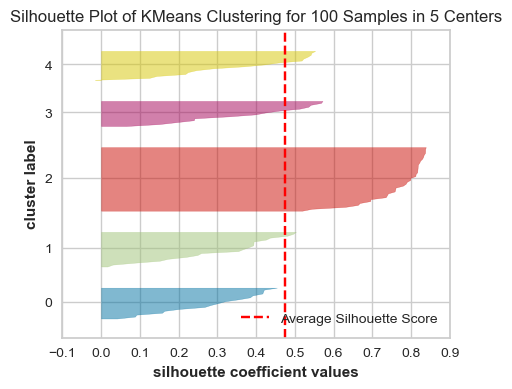

In [36]:
model = KMeans(5, n_init='auto', random_state=42)
visualizer = SilhouetteVisualizer(model, colors="yellowbrick")
visualizer.fit(XX)  # Fit the data to the visualizer
visualizer.show();
# Finalize and render the figure

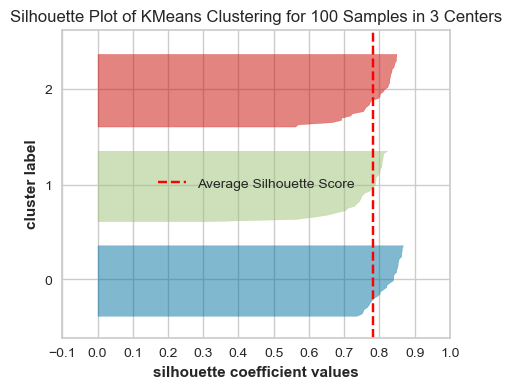

In [37]:
model = KMeans(3, n_init='auto', random_state=42)
visualizer = SilhouetteVisualizer(model, colors="yellowbrick")
visualizer.fit(XX)  # Fit the data to the visualizer
visualizer.show();
# Finalize and render the figure

**What to look for in these plots?**

- The thickness of each silhouette represents the size of that cluster. In the above plot, our three clusters are of similar sizes.

- The length (or area) of each silhouette indicates the "goodness" of each cluster.

- A slower dropoff (more rectangular) indicates more points are "happy" in their cluster.
- The red dashed line shows the average silhouette score for all samples, which tells you the overall clustering fit. The close this score is to 1, the better the clustering fit is. In our example, the average score seems to be around 0.78, which suggests a strong cluster structure.
- For a well-fitted clustering model, you'd expect to see the silhouette plots for each cluster above the average silhouette score line, and with widths which do not vary wildly.  
- In general, if any cluster has many points below the average silhouette score, this could be a sign that the cluster is not well separated from its neighbouring cluster, or it has too much internal variance, suggesting that the number of cluster chosen might not be ideal.
- We can apply Silhouette method to clustering methods other than K-Means.

**Limitations**

Neither measure establishes a true number of clusters. Elbows can be subjective, and both measures tend to favour compact, well-separated groups. They may be misleading for clusters with complex shapes, unequal densities, or application-specific meanings. Treat these plots as diagnostics and combine them with domain knowledge and qualitative inspection of the resulting clusters.

<br><br><br><br>

## Exercises

### Exercise 3

Select all statements that are true.

- (A) If you train K-Means with `n_clusters`= the number of examples, the inertia value will be 0. 

- (B) The elbow plot shows the tradeoff between within cluster distance and the number of clusters.
- (C) Unlike the Elbow method, the Silhouette method is not dependent on the notion of cluster centers.
- (D) The elbow plot is not a reliable method to obtain the optimal number of clusters in all cases. 
- (E) The Silhouette scores ranges between -1 and 1 where higher scores indicates better cluster assignments.

::: {.callout-tip collapse="true"}
## Solution

- A, B, C, D, E
:::

<br><br><br><br>

::: {.callout-note collapse="true" title="Optional: Gaussian mixture models"}

Gaussian mixture models (GMMs) provide a more flexible, probabilistic alternative to K-Means. They are not part of the core material for this chapter, but this section is available for readers who want to see how soft cluster assignments and non-spherical clusters can be handled.

### Motivation

K-Means represents every cluster only by a centroid, so it works best for compact, roughly spherical groups. Consider data containing elongated groups instead.

In [38]:
from scipy.stats import multivariate_normal, norm
from sklearn.datasets import make_blobs, make_circles, make_moons

dataset_sub1 = multivariate_normal.rvs(
    mean=[2, 4], cov=[[12, 11.5], [11.5, 12]], size=200, random_state=42
)

dataset_sub2 = multivariate_normal.rvs(
    mean=[11, -3], cov=[[12, -10], [-10, 12]], size=100, random_state=42
)

dataset_sub3,y = make_blobs(random_state=42, centers =1, cluster_std=1.8, n_samples=50)
dataset_sub4 = dataset_sub3 + np.array([4, -14])

X_train = np.vstack([dataset_sub1, dataset_sub2, dataset_sub4])
# X_train = np.vstack([dataset_sub1, dataset_sub2])

X_train.shape

(350, 2)

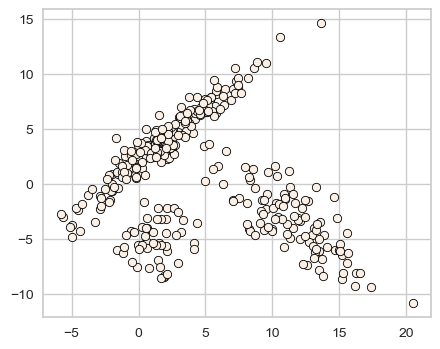

In [39]:
discrete_scatter(X_train[:,0], X_train[:,1],s=6);

How well does K-Means cluster these data?

In [40]:
km = KMeans(n_clusters=3, n_init="auto")
km.fit(X_train)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [41]:
km_labels = km.labels_

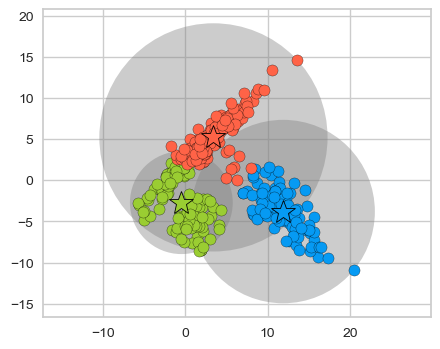

In [42]:
plot_kmeans_circles(km, X_train, n_clusters=3)

K-Means divides the space according to distance from the centroids and cannot capture these elongated groups well. A **Gaussian mixture model** (GMM) also models each component's spread and orientation through a covariance matrix.

In [43]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=3, covariance_type="full") # more on covariance_type in a bit 
gmm.fit(X_train)
gmm_labels = gmm.predict(X_train)

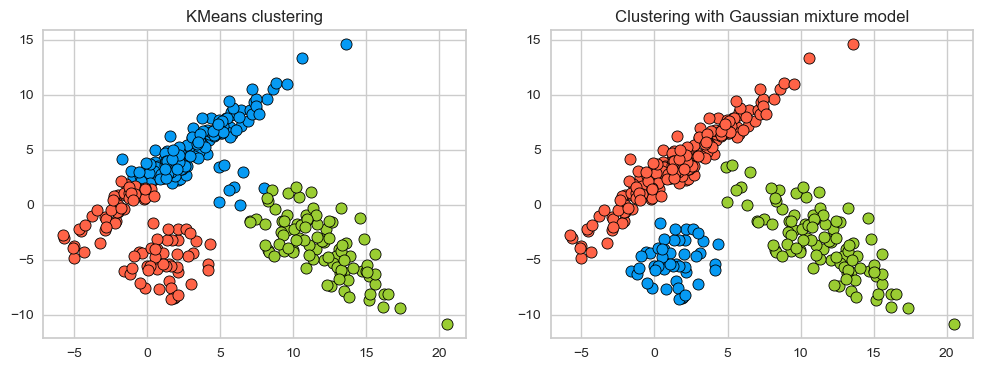

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4)) 
discrete_scatter(X_train[:, 0], X_train[:, 1], km_labels, c=gmm_labels, markers="o", ax=ax[0]);
ax[0].set_title('KMeans clustering')
discrete_scatter(X_train[:, 0], X_train[:, 1], gmm_labels, c=gmm_labels, markers="o", ax=ax[1]);
ax[1].set_title('Clustering with Gaussian mixture model');

On this toy dataset, the GMM captures the ellipse-shaped groups more naturally.

Each component has a mean vector, covariance matrix, and weight.

In [45]:
gmm.means_

array([[ 1.25596947, -5.15011412],
       [11.38137298, -3.31731115],
       [ 1.93609356,  3.96311554]])

Since our dataset is 2d, we get a 2d vector for the mean of each cluster.  

In [46]:
gmm.covariances_

array([[[ 1.97803583,  0.26628563],
        [ 0.26628563,  3.11174164]],

       [[ 9.09449493, -7.25892116],
        [-7.25892116,  9.394036  ]],

       [[10.95673803, 10.63462235],
        [10.63462235, 11.26072047]]])

Because our dataset is two-dimensional, we get a 2 by 2 covariance matrix for each cluster.

- There is a non-negative weight associated with each component which represents the proportion of total distribution contributed by that component.  

In [47]:
gmm.weights_

array([0.14042383, 0.28682168, 0.57275449])

We have trained our model with three components so we have three weights (prior probabilities) associated with each component. The sum of the weights is 1.0. 

In [48]:
np.sum(gmm.weights_)

np.float64(1.0)

<br><br><br><br>

### How does a GMM work?

- Given $K$, the number of clusters or the number of components, we want to fit Gaussian blobs to the data. Each Gaussian will have its own mean vector and covariance matrix. 

- This is a **generative model**; it models the probability of a given data point being generated from the mixture of the Gaussians.  

$$P(x) = \sum_{k=1}^{K} \pi_k \mathcal{N}(x \mid \mu_k, \Sigma_k)$$

- $x \rightarrow$ a data point

- $\pi_k \rightarrow$ the weight of component $k$, where $0 \leq \pi_k \leq 1$ and $\sum_{k=1}^{K} \pi_k = 1$
- $K \rightarrow$ the number of clusters or the number of components
- $k \rightarrow$ index of a component, where $k \in \{1, 2, \dots, K\}$
- $\mu_k \rightarrow$ the mean vector of component $k$
- $\Sigma_k \rightarrow$ the covariance matrix associated with component $k$

The generative story of the model assumes that each data point in the dataset is generated from one of the Gaussian components. So for each example $x$: 
- Choose component $k$ with probabilities proportional to the weight $\pi_k$ (prior probability) of the components. 

- Choose example $x$ from the Gaussian distribution associated with the $k^{th}$ component: $\mathcal{N}(x \mid \mu_k, \Sigma_k)$ 

How to interpret the weights associated with the Gaussians? Let's look at a toy example with of a mixture of Gaussians, i.e., a weighted sum of Gaussians. 


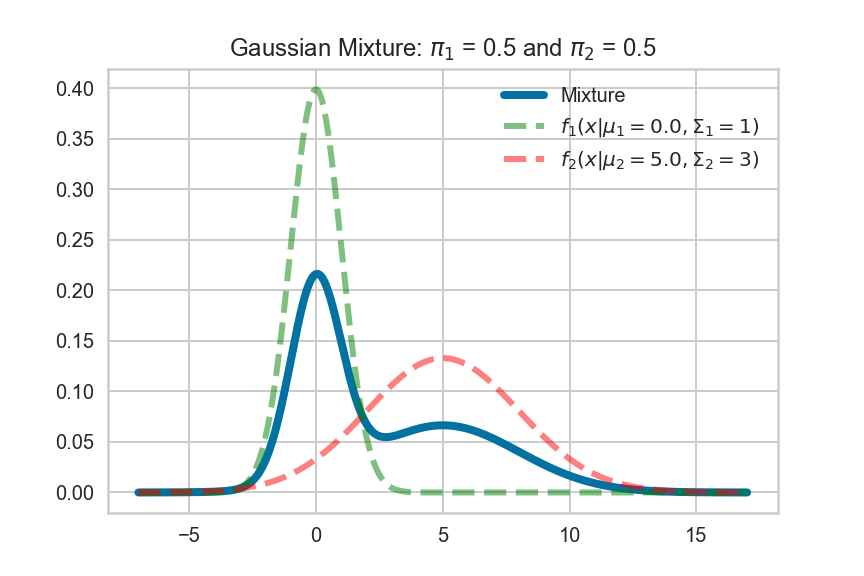
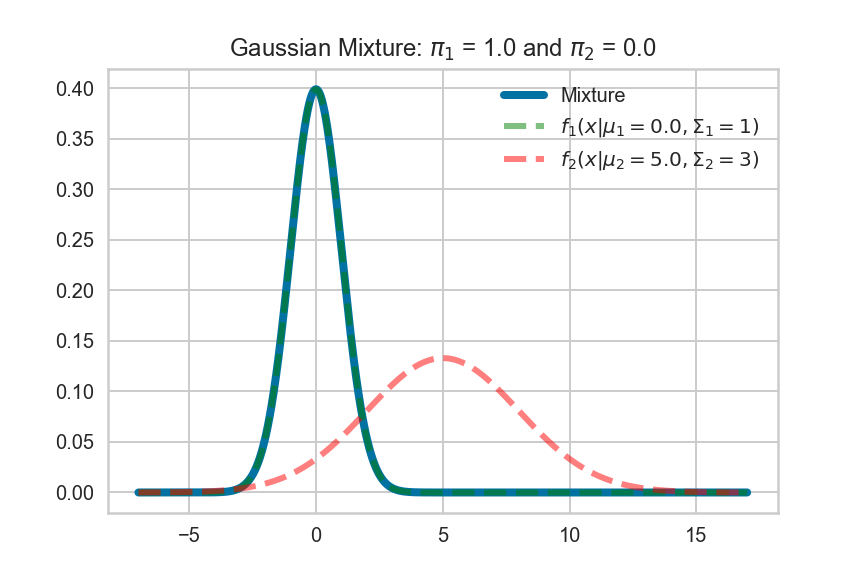
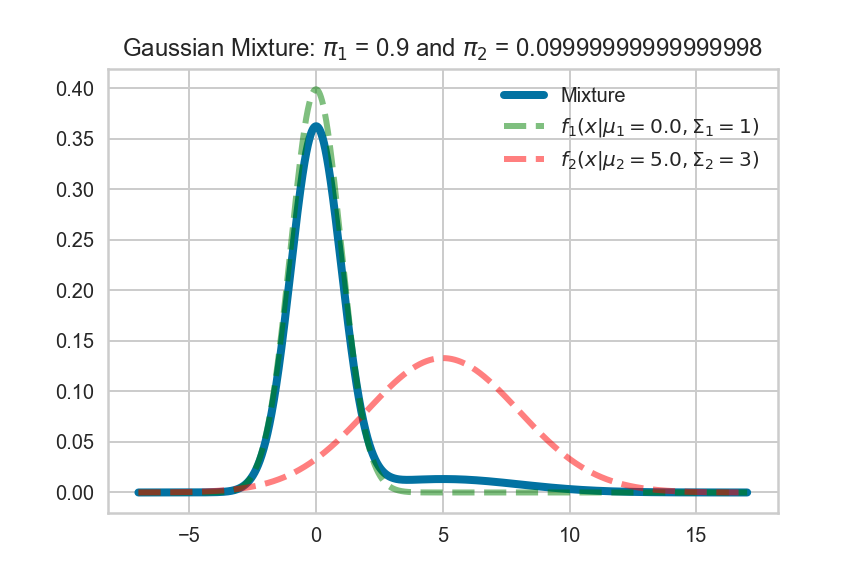
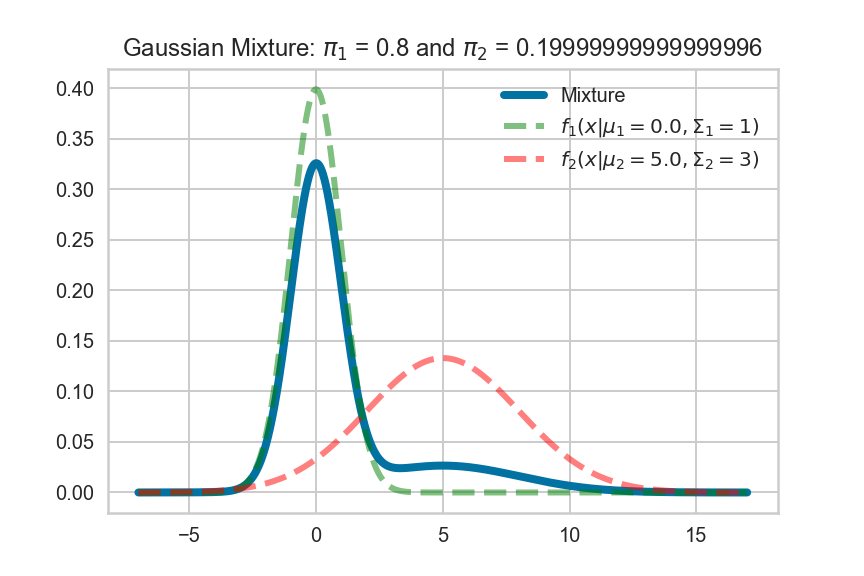
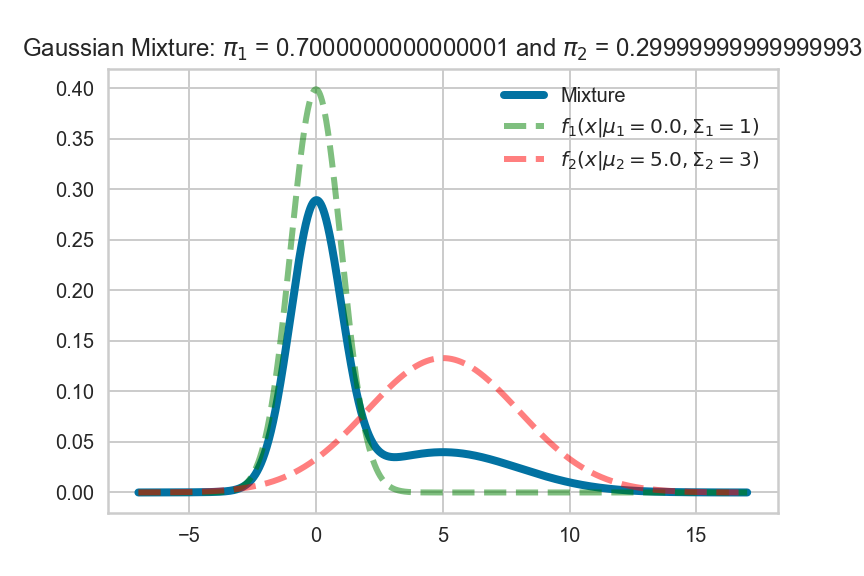
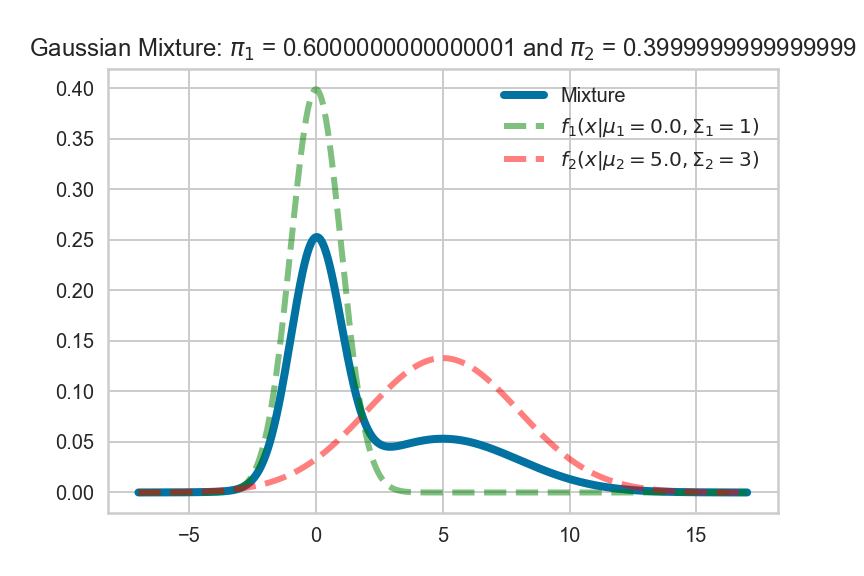
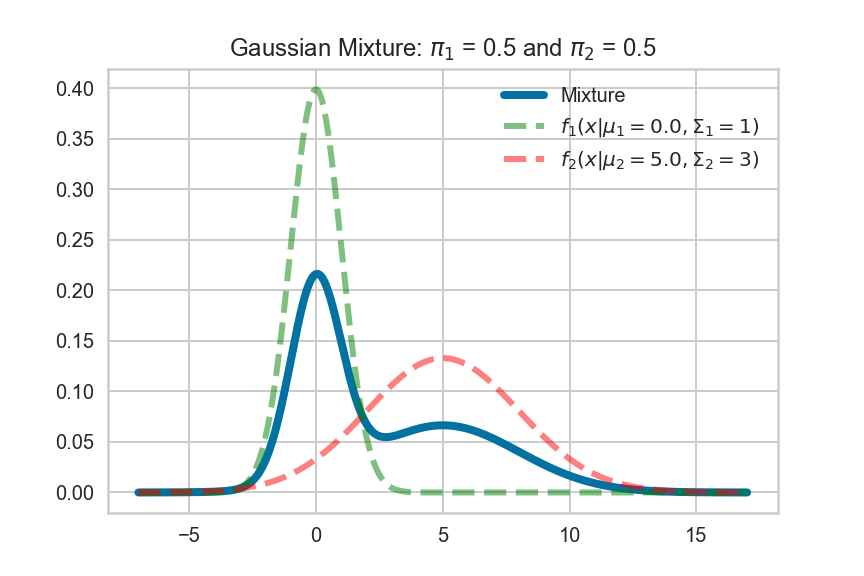
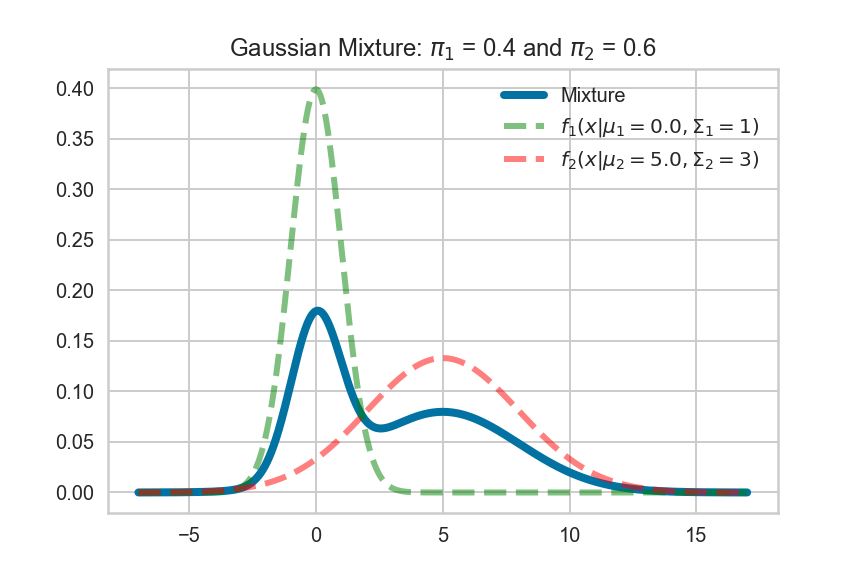
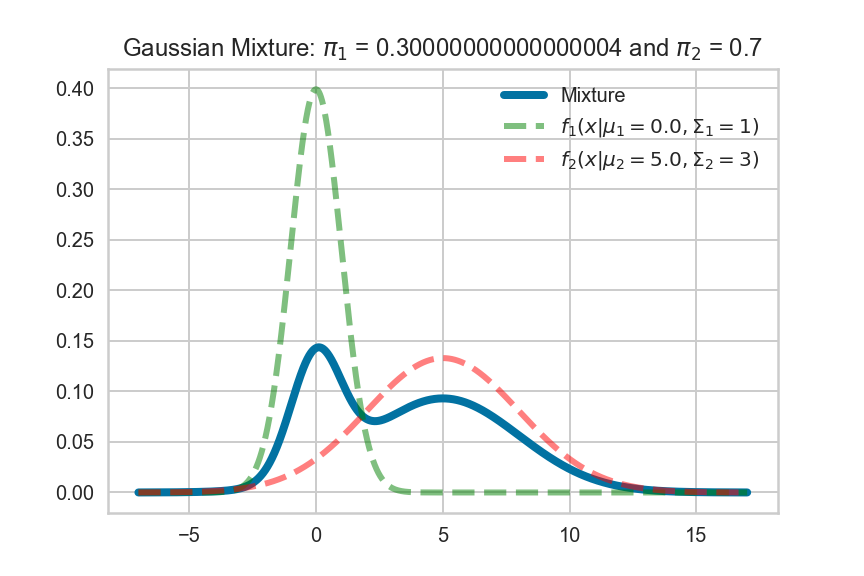
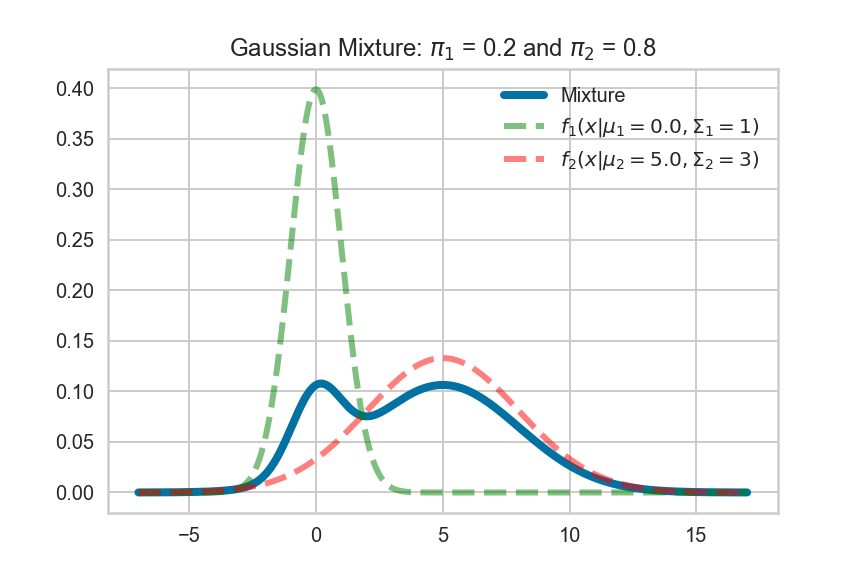
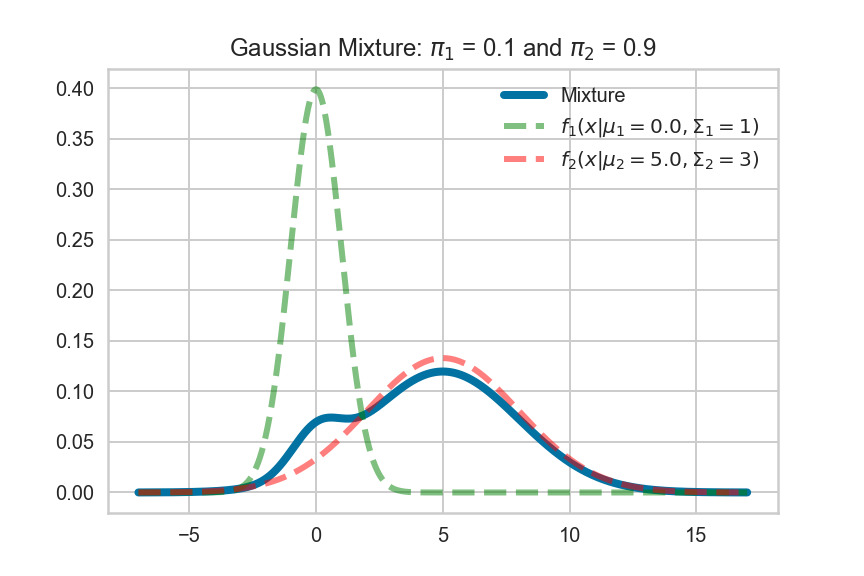
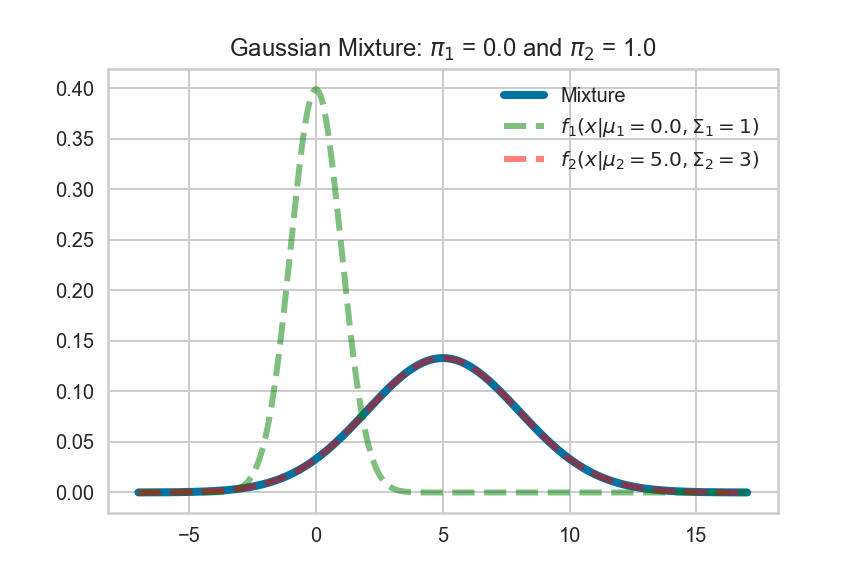

In [49]:
def f(ϕ1):
    fig = plt.figure(figsize=(6,4))        
    return Gaussian_mixture_1d(ϕ1=ϕ1, ϕ2=1-ϕ1, fig=fig)
    
interact(f, ϕ1=widgets.FloatSlider(start=0, end=1.0, step=0.1, value=0.5)).embed(max_opts=11)
#interact(f, ϕ1=widgets.FloatSlider(start=0, end=1.0, step=0.1, value=0.5))

- A mixture of Gaussians can model much more complicated shapes than a single Gaussian distribution. 

The goal is to estimate $\pi_k$, $\mu_k$, $\Sigma_k$ for all clusters or components $k$. 
- It's a non-convex optimization problem 

- It is sensitive to initialization. Usually, it's initialized with K-Means. 
- Generally used with "soft" assignments. Each point contributes to the mean and covariance of each component but the points that are far away only contribute a little.  

Under the hood it finds these parameters using an algorithm called **Expectation Maximization**. The idea is to treat the clusters as **hidden variables**. 

- Choose starting guesses for the location and shape

- Repeat until converged:
    - E-step: for each point, find weights encoding the probability of membership in each cluster
    
    - M-step: for each cluster, update its location, normalization, and shape based on all data points, making use of the weights
    

We can constrain the covariance of the Gaussians using the `covariance_type` option when creating a `GaussianMixture` object. This allows us to control the shape and complexity of clusters. 

Let's look at four types supported in `sklearn`:  

In [50]:
k=3
estimators = {
    cov_type: GaussianMixture(
        n_components=k, covariance_type=cov_type, max_iter=20, random_state=0
    )
    for cov_type in ["spherical", "diag", "tied", "full"]
}

In [51]:
estimators['spherical'].fit(X_train).covariances_

array([7.09940051, 6.72515023, 8.24294885])

In [52]:
estimators['diag'].fit(X_train).covariances_

array([[ 6.15589073,  6.73691637],
       [ 6.79476523,  6.97405866],
       [ 4.8085368 , 13.59126014]])

In [53]:
estimators['tied'].fit(X_train).covariances_

array([[6.6189311 , 0.61972005],
       [0.61972005, 8.18723636]])

In [54]:
estimators['full'].fit(X_train).covariances_

array([[[10.95673803, 10.63462235],
        [10.63462235, 11.26072047]],

       [[ 9.09449493, -7.25892116],
        [-7.25892116,  9.394036  ]],

       [[ 1.97803583,  0.26628563],
        [ 0.26628563,  3.11174164]]])

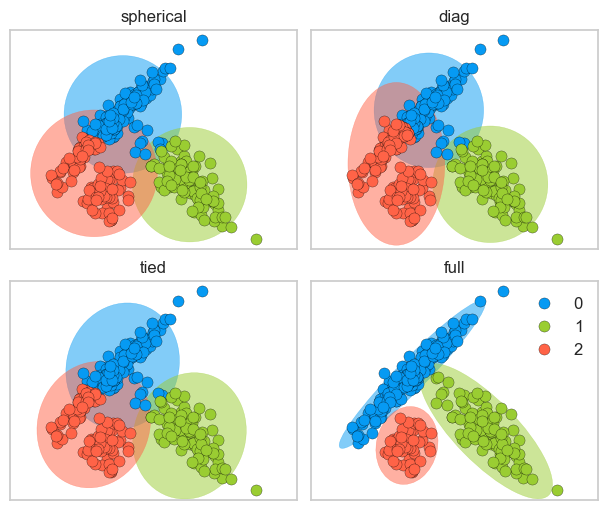

In [55]:
plot_gmm_cov_types(estimators, X_train) # user-defined function from code/plotting_functions.py

- spherical: each component has its own single variance

- diag: each component has its own diagonal covariance matrix which results in axis-aligned clusters 

- tied: all components share the same general covariance matrix which results in Gaussian components with the same shape and orientations  
- full: each component has its own general covariance matrix which results in Gaussian components with different shapes and different orientations 

Since GMMs do soft cluster assignment, we can get prediction probabilities. Below are the cluster membership probabilities for a few data points. 

In [56]:
pd.DataFrame(estimators['full'].predict_proba(X_train)[10:20]).round(4)

,0,1,2
0,0.9996,0.0000,0.0004
1,0.9899,0.0101,0.0000
2,0.9966,0.0034,0.0000
3,0.9999,0.0001,0.0000
4,0.9961,0.0039,0.0000
5,0.9935,0.0065,0.0000
6,0.9927,0.0073,0.0000
7,0.9981,0.0000,0.0019
8,0.9839,0.0157,0.0003
9,1.0000,0.0000,0.0000


**Model selection with AIC and BIC**

Since GMM is a generative model, we can get the log likelihood of the model generating this data. 

In [57]:
estimators['full'].score(X_train)

np.float64(-5.073780282241251)

It's possible to do model selection, i.e., selecting the appropriate covariance type and the number of components based on Akaike Information Criterion (AIC) or Bayesian Information Criterion (BIC) which penalize complex models. 

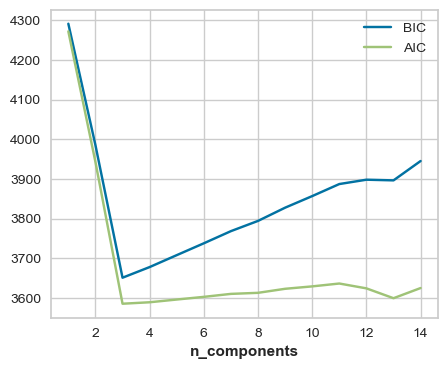

In [58]:
n_components = range(1,15)

gmm_models = [GaussianMixture(n_components=k).fit(X_train) for k in n_components]
aic_scores = [model.aic(X_train) for model in gmm_models]
bic_scores = [model.bic(X_train) for model in gmm_models]

data = np.vstack([n_components, aic_scores, bic_scores]).T
pd.DataFrame(data, columns=['n_components', 'aic', 'bic'])
np.argmin(bic_scores)
plt.plot(n_components, bic_scores, label='BIC')
plt.plot(n_components, aic_scores, label='AIC')
plt.legend(loc='best')
plt.xlabel('n_components');

Here, both AIC and BIC are smallest for `n_components=3`. See an example of using grid search to select the number of components using BIC [here](https://scikit-learn.org/stable/auto_examples/mixture/plot_gmm_selection.html#sphx-glr-auto-examples-mixture-plot-gmm-selection-py).

### Optional exercise

Select all statements that are true.

- (A) GMMs are more flexible than KMeans but can be computationally expensive. 

- (B) In GMMs, each data point has a probability associated with each component. 

- (C) GMMs are sensitive to the initialization. 

- (D) The number of components in a GMM has no effect on the model's ability to fit the data. 

::: {.callout-tip collapse="true"}
## Solution

- A, B, C
:::

:::

## Summary

- **No targets are needed.** Clustering looks for structure in $X$ without using a target $y$.
- **Assign, average, repeat.** K-Means assigns each example to its nearest centroid, recomputes the centroids as means, and repeats until they stabilize.
- **Cluster labels are just names.** Labels such as 0, 1, and 2 identify groups but have no numerical meaning.
- **Representation defines similarity.** Feature choice and scaling determine which examples are close under Euclidean distance.
- **K-Means has a preferred cluster shape.** It works best for compact, roughly spherical, similarly sized clusters and can be strongly affected by outliers.
- **Initialization matters.** K-Means can converge to a suboptimal solution, so K-Means++ and multiple initializations are useful.
- **There is rarely one correct $K$.** Elbow and silhouette plots provide evidence, but useful clusters must also be interpretable and meaningful for the application.

<br><br><br><br>

## Resources
- ["Spaghetti Sauce" talk by Malcom Gladwell](https://www.ted.com/talks/malcolm_gladwell_on_spaghetti_sauce?language=en)
- [A Comprehensive Survey of Clustering Algorithms](https://link.springer.com/article/10.1007/s40745-015-0040-1)
- [Visualizing-k-means-clustering](https://www.naftaliharris.com/blog/visualizing-k-means-clustering/) 
- [Visualizing K-Means algorithm with D3.js](http://tech.nitoyon.com/en/blog/2013/11/07/k-means/)
- [Clustering with Scikit with GIFs](https://dashee87.github.io/data%20science/general/Clustering-with-Scikit-with-GIFs/)
- [`sklearn` clustering documentation](https://scikit-learn.org/stable/modules/clustering.html)